CELL 1 : ***Import Dependencies***  

In [2]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt
import numpy as np
import os

CELL 2 : ***Constants***

In [3]:
BATCH_SIZE = 4
IMAGE_SIZE = 128
CHANNELS = 3
EPOCHS = 20

CELL 3 : ***Check Classes***

In [5]:
class_names = dataset.class_names
print(class_names)
print("Number of classes:",len(class_names))

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Number of classes: 15


CELL 4 : ***Load Dataset***

In [4]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 20638 files belonging to 15 classes.


CELL 5 : ***Visualize Images***

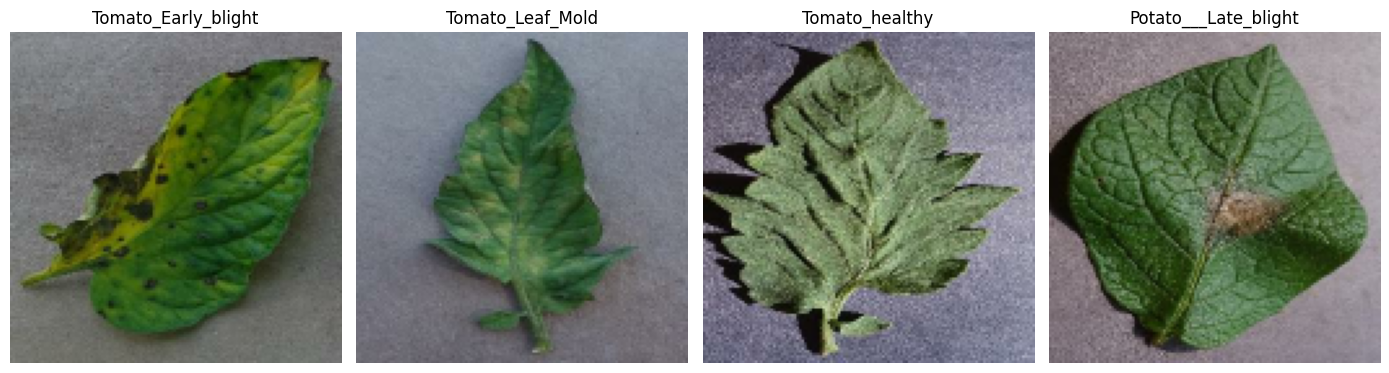

In [6]:
plt.figure(figsize=(14,14))
for image_batch, lables_batch in dataset.take(1):
    for i in range(4):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[int(lables_batch[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()

CELL 6 : ***Dataset Partition Function***

In [7]:
def get_dataset_partitions_tf(
    ds,
    train_split=0.8,
    val_split=0.1,
    test_split=0.1,
    shuffle=True,
    shuffle_size=10000
):
    assert (train_split + val_split + test_split) == 1
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    return train_ds,val_ds,test_ds

CELL 7 : ***Split Dataset***

In [8]:
train_ds,val_ds,test_ds = get_dataset_partitions_tf(dataset)
print("Train batches:",len(train_ds))
print("Validation batches:",len(val_ds))
print("test batches:",len(test_ds))

Train batches: 4128
Validation batches: 516
test batches: 516


CELL 8 : ***Cache,Shuffle and Prefetch***

In [9]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

CELL 9 : ***Resize and Rescale***

In [10]:
resize_and_rescale = tf.keras.Sequential([layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),layers.Rescaling(1./255),])

CELL 10 : ***Data Augmentation***

In [11]:
data_augmentation = tf.keras.Sequential([layers.RandomFlip("horizontal_and_vertical"),layers.RandomRotation(0.2),])

CELL 11 : ***Apply Data Augmentation***

In [12]:
train_ds = train_ds.map(lambda x,y:(data_augmentation(x,training=True),y)).prefetch(buffer_size=AUTOTUNE)

CELL 12 : ***Define Input Shape And Number Of Class***

In [13]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes=len(class_names)
print("Number of Classes:",
    n_classes)

Number of Classes: 15


CELL 13 : ***Build CNN Model***

In [14]:
input_shape = (BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,CHANNELS)
model = models.Sequential([resize_and_rescale,
                           layers.Conv2D(32,kernel_size=(3,3), activation='relu'),
                           layers.MaxPooling2D((2,2)),
                           layers.Conv2D(64,kernel_size=(3,3), activation='relu'),
                           layers.MaxPooling2D((2,2)),
                           layers.Conv2D(128,kernel_size=(3,3), activation='relu'),
                           layers.MaxPooling2D((2,2)),
                           layers.Conv2D(128,kernel_size=(3,3), activation='relu'),
                           layers.MaxPooling2D((2,2)),
                           layers.Conv2D(256,kernel_size=(3,3), activation='relu'),
                           layers.MaxPooling2D((2,2)),
                           layers.Flatten(),
                           layers.Dense(256, activation='relu'),
                           layers.Dropout(0.3),
                           layers.Dense(128, activation='relu'),
                           layers.Dropout(0.3),
                           layers.Dense(len(class_names),activation='softmax')])
model.build(input_shape=input_shape)
model.summary()
                           

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (4, 128, 128, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (4, 126, 126, 32)      │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (4, 63, 63, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (4, 61, 61, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (4, 30, 30, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (4, 28, 28, 128)       │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (4, 14, 14, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (4, 12, 12, 128)       │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (4, 6, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (4, 4, 4, 256)         │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (4, 2, 2, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (4, 1024)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (4, 256)               │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (4, 256)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (4, 128)               │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (4, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (4, 15)                │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833,231 (3.18 MB)

 Trainable params: 833,231 (3.18 MB)

 Non-trainable params: 0 (0.00 B)

CELL 14 : ***Compile Model***

In [17]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])


CELL 15 : ***Train Model***

In [18]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS
)

Epoch 1/20
4128/4128 ━━━━━━━━━━━━━━━━━━━━ 521s 115ms/step - accuracy: 0.2665 - loss: 2.2274 - val_accuracy: 0.3605 - val_loss: 1.8609
Epoch 2/20
4128/4128 ━━━━━━━━━━━━━━━━━━━━ 517s 125ms/step - accuracy: 0.4267 - loss: 1.7607 - val_accuracy: 0.5170 - val_loss: 1.4771
Epoch 3/20
4128/4128 ━━━━━━━━━━━━━━━━━━━━ 456s 110ms/step - accuracy: 0.5234 - loss: 1.4377 - val_accuracy: 0.5925 - val_loss: 1.1627
Epoch 4/20
4128/4128 ━━━━━━━━━━━━━━━━━━━━ 438s 106ms/step - accuracy: 0.5755 - loss: 1.2455 - val_accuracy: 0.6483 - val_loss: 0.9690
Epoch 5/20
4128/4128 ━━━━━━━━━━━━━━━━━━━━ 454s 110ms/step - accuracy: 0.6217 - loss: 1.0971 - val_accuracy: 0.6875 - val_loss: 0.8504
Epoch 6/20
4128/4128 ━━━━━━━━━━━━━━━━━━━━ 487s 106ms/step - accuracy: 0.6549 - loss: 1.0105 - val_accuracy: 0.6749 - val_loss: 0.8891
Epoch 7/20
4128/4128 ━━━━━━━━━━━━━━━━━━━━ 422s 102ms/step - accuracy: 0.6776 - loss: 0.9403 - val_accuracy: 0.7229 - val_loss: 0.7721
Epoch 8/20
4128/4128 ━━━━━━━━━━━━━━━━━━━━ 434s 105ms/step - ac

CELL 16 : ***Evaluate Model***

In [19]:
scores = model.evaluate(test_ds)
print("Loss :", scores[0])
print("Accuracy :", scores[1])

516/516 ━━━━━━━━━━━━━━━━━━━━ 77s 33ms/step - accuracy: 0.8668 - loss: 0.4071
Loss : 0.40705588459968567
Accuracy : 0.8667635917663574


CELL 17 : ***Accuracy And Loss Graph***

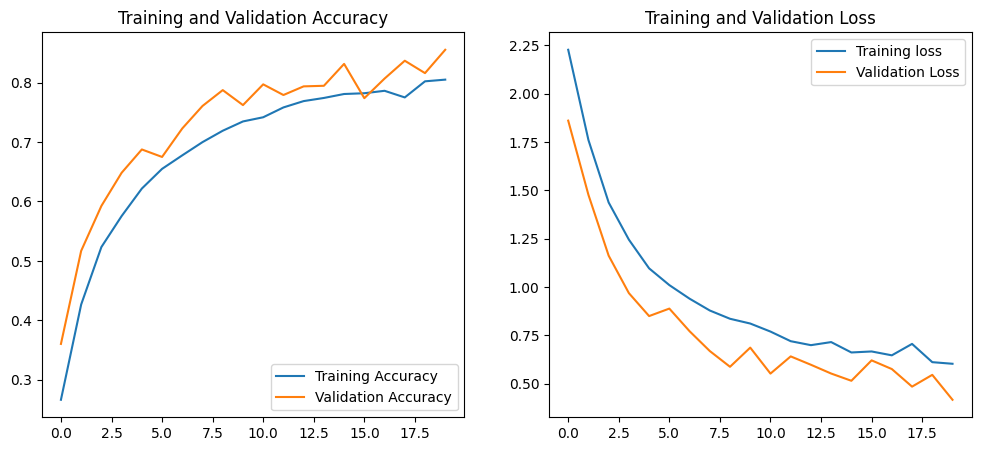

In [20]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.subplot(1,2,2)
plt.plot(loss, label='Training loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc= 'upper right')
plt.title('Training and Validation Loss')
plt.show()

CELL 18 : ***Test Prediction On One Image***

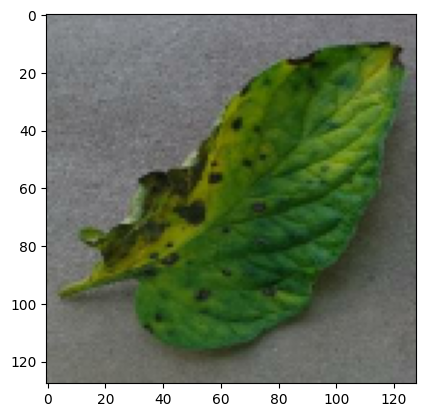

Actual lable : Tomato__Tomato_YellowLeaf__Curl_Virus
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step
predicted Lable : Tomato__Tomato_YellowLeaf__Curl_Virus


In [21]:
import numpy as np
for images_batch, lables_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype('uint8')
    first_lable = lables_batch[0].numpy()
    plt.imshow(first_image)
    plt.show()
    print("Actual lable :",class_names[first_lable])
    batch_prediction = model.predict(images_batch)
    print("predicted Lable :",class_names[np.argmax(batch_prediction[0])])

CELL 19 : ***Prediction Function***

In [22]:
import numpy as np
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]),2)
    return predicted_class,confidence

CELL 20 : ***Predict Multiple Images***

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

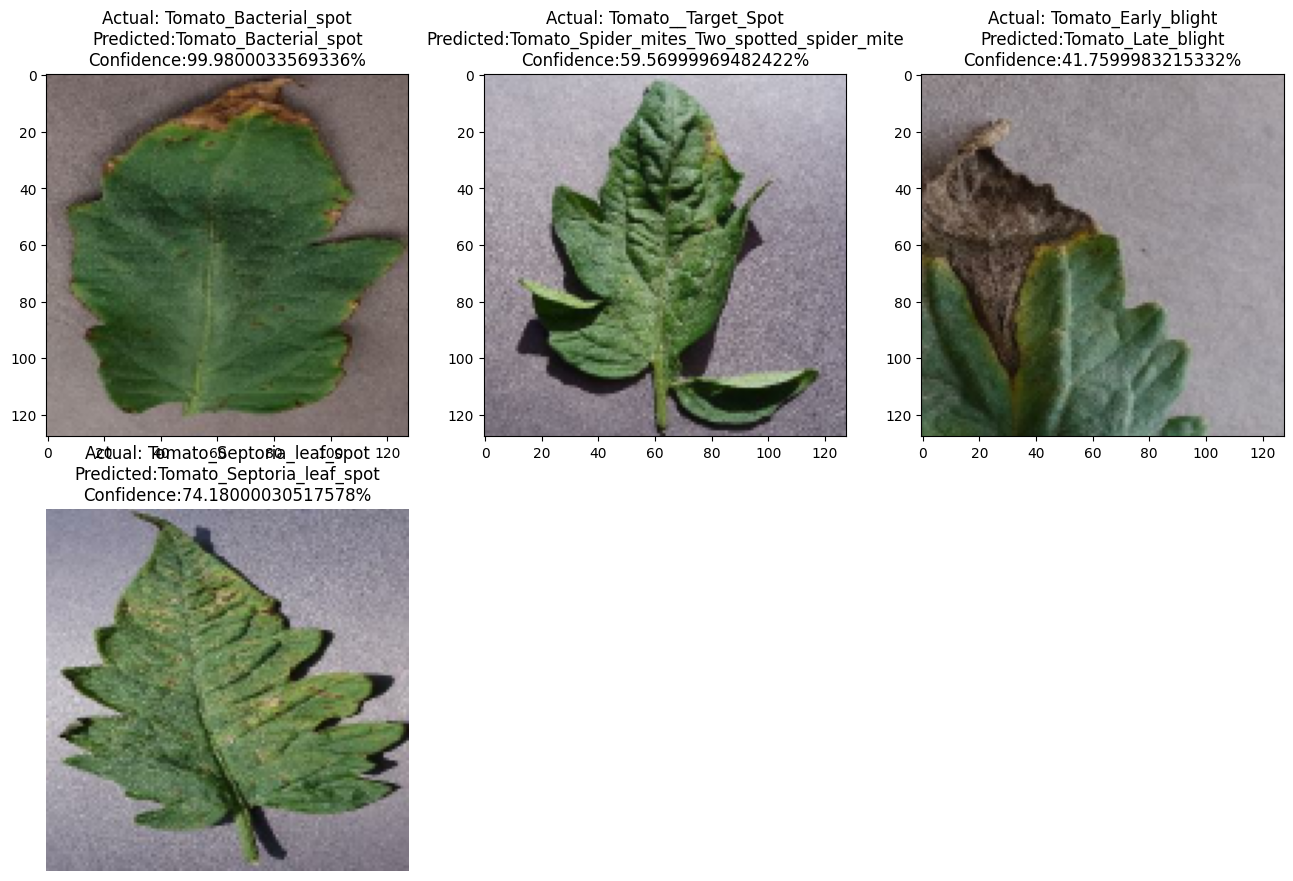

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16,16))
for images, labels in test_ds.take(1):
    for i in range(4):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_class, confidence = predict(model,images[i])
        actual_class = class_names[labels[i]]
        plt.title(f"Actual: {actual_class}\n" f"Predicted:{predicted_class}\n" f"Confidence:{confidence}%")
plt.axis("off")

CELL 21 : ***Save Tensor Flow Model***

In [24]:
model.save("plant_disease_model.keras")

CELL 22 : ***Save H5 Model***

In [25]:
model.save("plant_disease_model.h5")

CELL 23 : ***Load Saved Model Later***

In [26]:
loaded_model = tf.keras.models.load_model("plant_disease_model.keras")

In [27]:
import tensorflow as tf
import numpy as np
import PIL

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__)
print("NumPy:", np.__version__)
print("Pillow:", PIL.__version__)

TensorFlow: 2.21.0
Keras: 3.12.3
NumPy: 2.2.6
Pillow: 12.3.0


In [28]:
model.save("plant_disease_model2.keras", include_optimizer=False)

******COMPLETED******